In [2]:
from google.colab import files

uploaded = files.upload()

Saving student_performance.csv to student_performance.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("student_performance.csv")

df.head()

,Student,Gender,Department,Study_Hours,Attendance,Marks,Projects,Placement
0,Student_1,Female,CSE,4,85,78,2,Yes
1,Student_2,Male,ECE,3,78,65,1,No
2,Student_3,Female,CSE,5,92,88,3,Yes
3,Student_4,Male,EEE,2,70,58,1,No
4,Student_5,Female,IT,6,88,82,2,Yes


In [4]:
import pandas as pd

df = pd.read_csv("student_performance.csv")

df

,Student,Gender,Department,Study_Hours,Attendance,Marks,Projects,Placement
0,Student_1,Female,CSE,4,85,78,2,Yes
1,Student_2,Male,ECE,3,78,65,1,No
2,Student_3,Female,CSE,5,92,88,3,Yes
3,Student_4,Male,EEE,2,70,58,1,No
4,Student_5,Female,IT,6,88,82,2,Yes
5,Student_6,Male,CSE,7,95,91,4,Yes
6,Student_7,Female,ECE,4,82,75,2,Yes
7,Student_8,Male,IT,5,90,86,3,Yes
8,Student_9,Female,CSE,8,96,94,5,Yes
9,Student_10,Male,EEE,3,75,68,1,No


In [5]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
display(df.describe())

Shape: (30, 8)

Columns:
Index(['Student', 'Gender', 'Department', 'Study_Hours', 'Attendance', 'Marks',
       'Projects', 'Placement'],
      dtype='object')

Missing Values:
Student        0
Gender         0
Department     0
Study_Hours    0
Attendance     0
Marks          0
Projects       0
Placement      0
dtype: int64

Statistical Summary:


,Study_Hours,Attendance,Marks,Projects
count,30.000000,30.000000,30.000000,30.000000
mean,5.133333,85.933333,80.933333,2.666667
std,1.960530,8.419736,12.039972,1.295439
min,2.000000,68.000000,55.000000,1.000000
25%,4.000000,81.250000,75.250000,2.000000
50%,5.000000,88.000000,84.500000,3.000000
75%,6.750000,92.000000,89.750000,3.750000
max,9.000000,98.000000,98.000000,5.000000


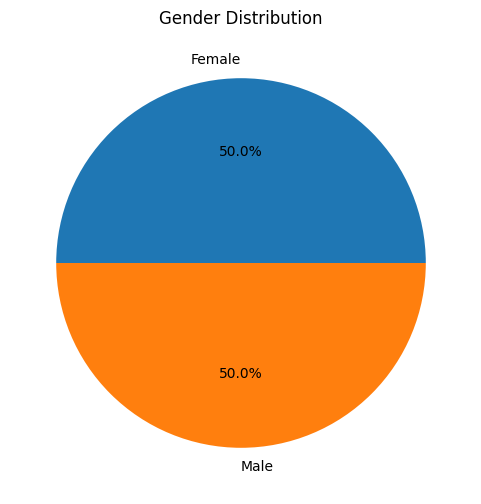

In [6]:
def plot_pie(data, labels, title="Pie Chart"):
    plt.figure(figsize=(6,6))
    plt.pie(data, labels=labels, autopct='%1.1f%%')
    plt.title(title)
    plt.show()

gender_counts = df["Gender"].value_counts()

plot_pie(
    gender_counts.values,
    gender_counts.index,
    "Gender Distribution"
)

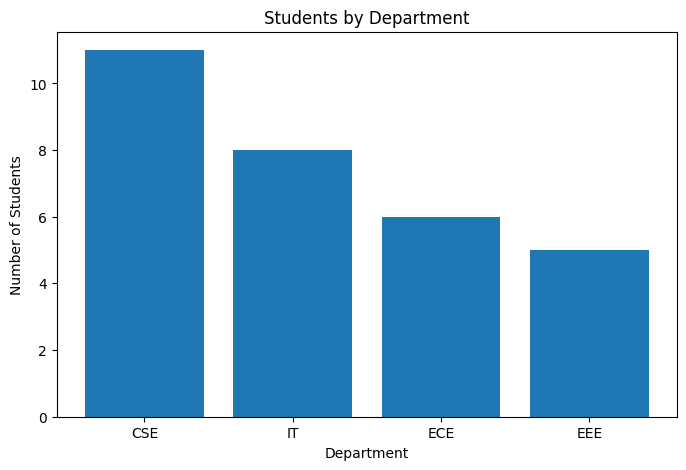

In [7]:
def plot_bar(categories, values, title="Bar Chart"):
    plt.figure(figsize=(8,5))
    plt.bar(categories, values)
    plt.title(title)
    plt.xlabel("Department")
    plt.ylabel("Number of Students")
    plt.show()

department_counts = df["Department"].value_counts()

plot_bar(
    department_counts.index,
    department_counts.values,
    "Students by Department"
)

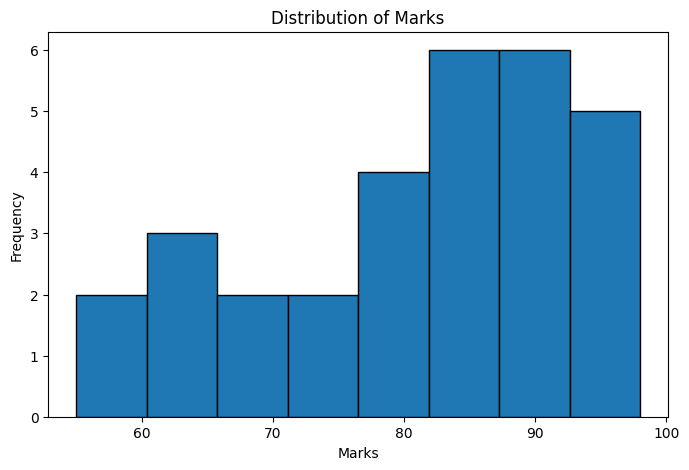

In [8]:
def plot_histogram(df, column):
    plt.figure(figsize=(8,5))
    plt.hist(df[column], bins=8, edgecolor="black")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.title("Distribution of " + column)
    plt.show()

plot_histogram(df, "Marks")

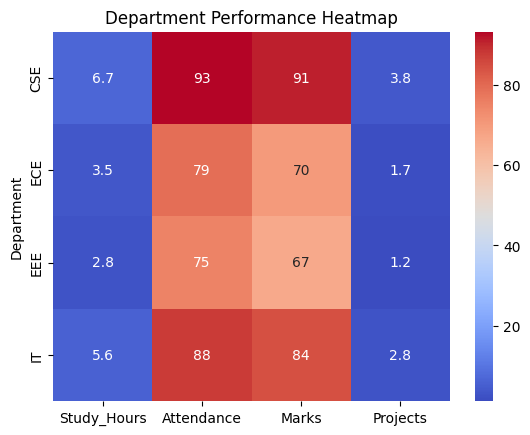

In [9]:
heatmap_data = df.groupby("Department")[
    ["Study_Hours", "Attendance", "Marks", "Projects"]
].mean()

sns.heatmap(
    heatmap_data,
    annot=True,
    cmap="coolwarm"
)

plt.title("Department Performance Heatmap")
plt.show()

In [10]:
import plotly.express as px

country_data = pd.DataFrame({
    "Country": ["India", "USA", "UK", "Canada", "Australia"],
    "Students": [500, 300, 200, 150, 100]
})

fig = px.choropleth(
    country_data,
    locations="Country",
    locationmode="country names",
    color="Students",
    title="Student Distribution by Country"
)

fig.show()

In [11]:
!pip install wordcloud

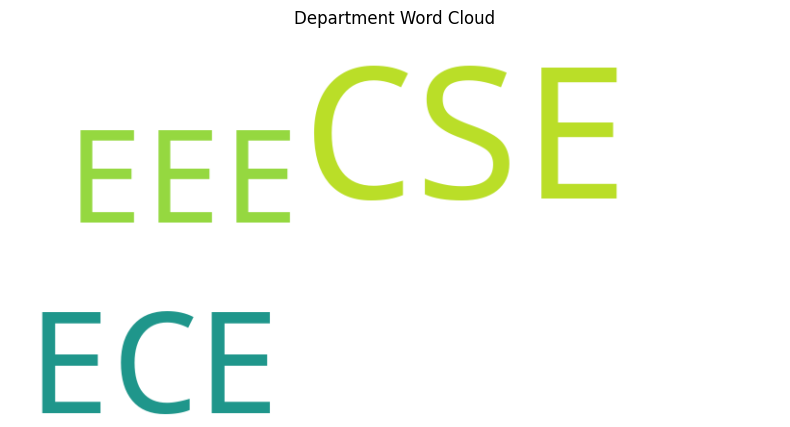

In [12]:
from wordcloud import WordCloud

text = " ".join(df["Department"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Department Word Cloud")
plt.show()

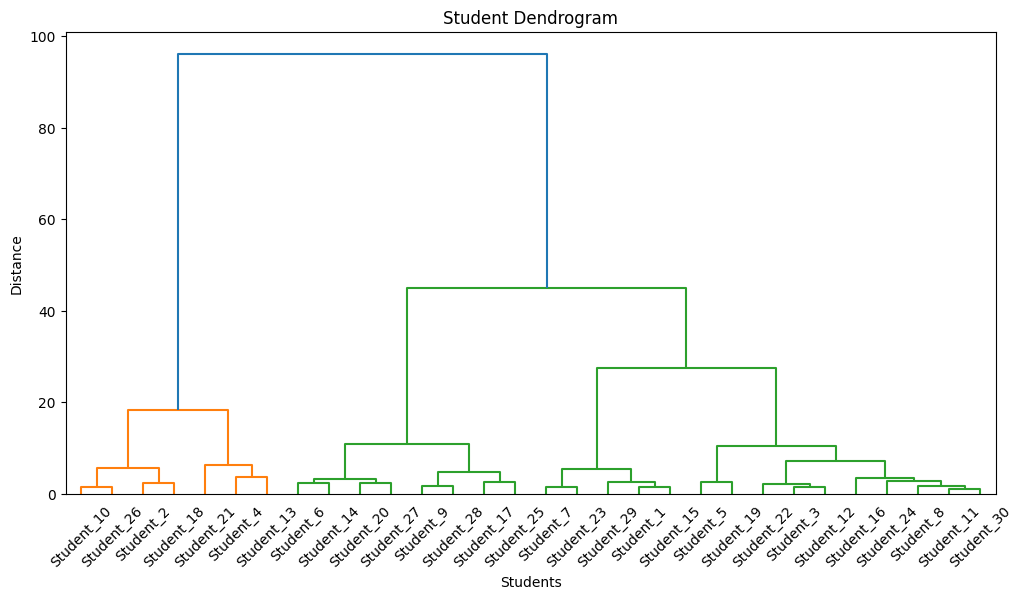

In [13]:
from scipy.cluster.hierarchy import dendrogram, linkage

data = df[
    ["Study_Hours", "Attendance", "Marks", "Projects"]
]

linked = linkage(data, method="ward")

plt.figure(figsize=(12,6))

dendrogram(
    linked,
    labels=df["Student"].values
)

plt.title("Student Dendrogram")
plt.xlabel("Students")
plt.ylabel("Distance")
plt.show()

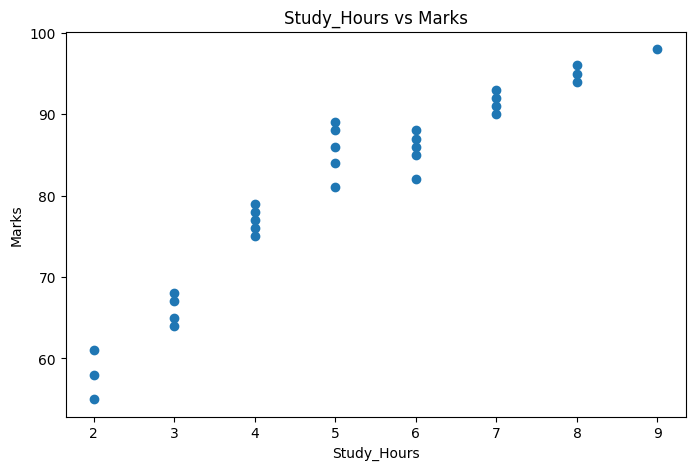

In [14]:
def scatter(x, y):
    plt.figure(figsize=(8,5))
    plt.scatter(x, y)
    plt.xlabel(x.name)
    plt.ylabel(y.name)
    plt.title(f"{x.name} vs {y.name}")
    plt.show()

scatter(
    df["Study_Hours"],
    df["Marks"]
)

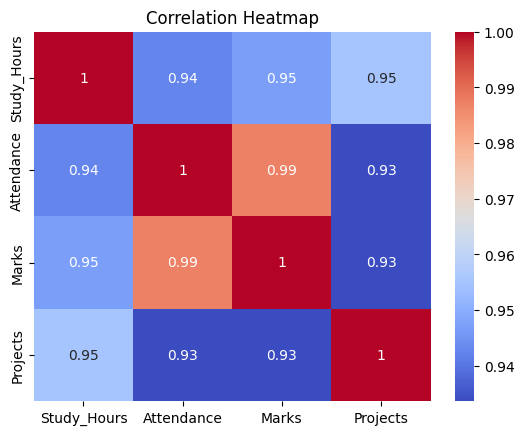

In [15]:
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

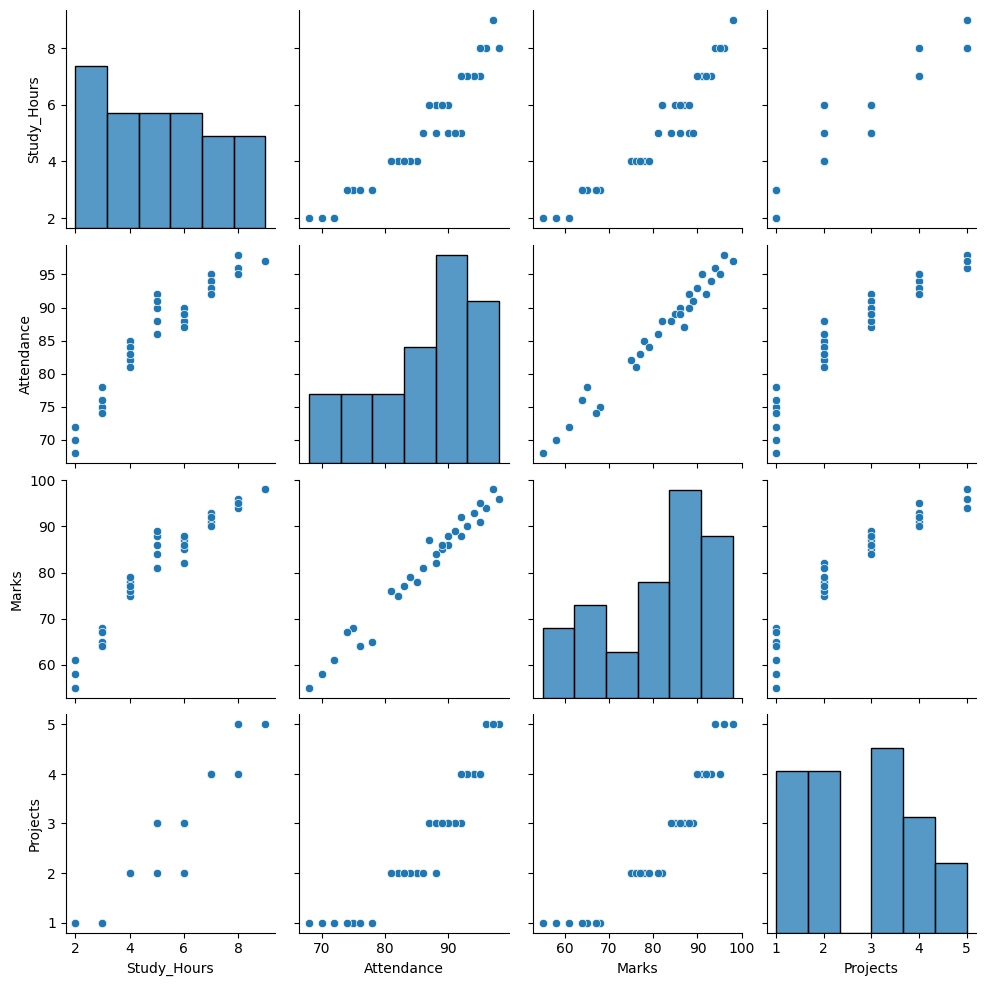

In [16]:
sns.pairplot(
    df[
        ["Study_Hours", "Attendance", "Marks", "Projects"]
    ]
)

plt.show()

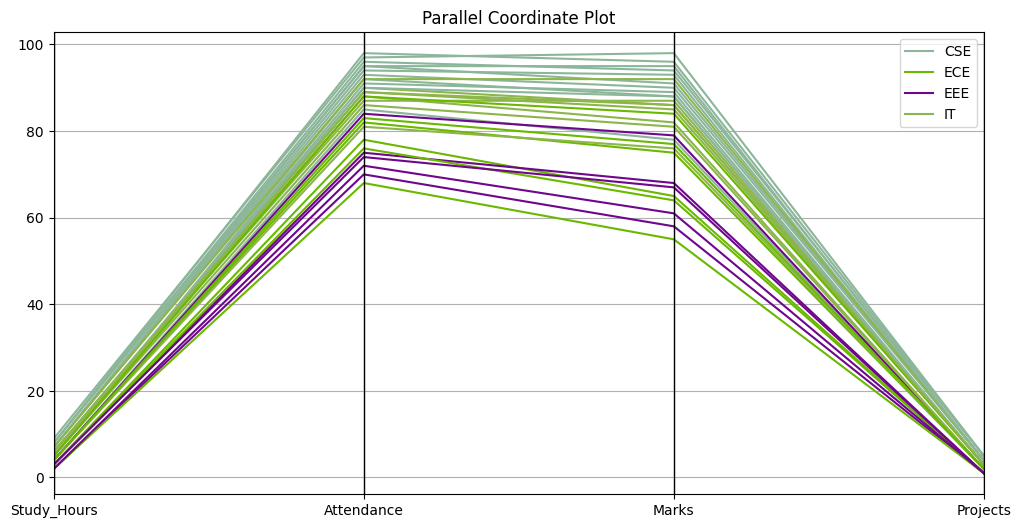

In [17]:
from pandas.plotting import parallel_coordinates

parallel_df = df[
    ["Department", "Study_Hours", "Attendance", "Marks", "Projects"]
]

plt.figure(figsize=(12,6))

parallel_coordinates(
    parallel_df,
    "Department"
)

plt.title("Parallel Coordinate Plot")
plt.show()

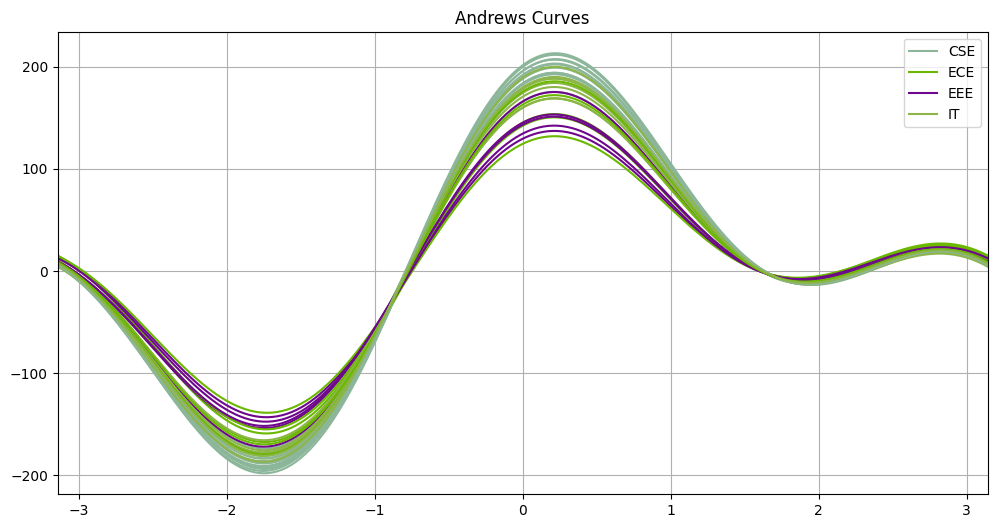

In [18]:
from pandas.plotting import andrews_curves

andrews_df = df[
    ["Department", "Study_Hours", "Attendance", "Marks", "Projects"]
]

plt.figure(figsize=(12,6))

andrews_curves(
    andrews_df,
    "Department"
)

plt.title("Andrews Curves")
plt.show()